In [ ]:
import pandas as pd
df = pd.read_csv("crop_yield.csv")
df.head()

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


In [ ]:
#Informações gerais sobre o conjunto de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


In [ ]:
#Verificando se existem valores ausentes
df.isnull().sum()

,0
Crop,0
Precipitation (mm day-1),0
Specific Humidity at 2 Meters (g/kg),0
Relative Humidity at 2 Meters (%),0
Temperature at 2 Meters (C),0
Yield,0


In [ ]:
#Culturas agricolas presentes no conjunto de dados
print(df["Crop"].unique())
#Quantidade de registros por cultura
print("\nQuantidade de registros por cultura:")
print(df["Crop"].value_counts())

['Cocoa, beans' 'Oil palm fruit' 'Rice, paddy' 'Rubber, natural']

Quantidade de registros por cultura:
Crop
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39
Name: count, dtype: int64


In [ ]:
#Preparando os dados numericos para a clusterização
from sklearn.preprocessing import StandardScaler
colunas_cluster = ["Precipitation (mm day-1)","Specific Humidity at 2 Meters (g/kg)","Relative Humidity at 2 Meters (%)","Temperature at 2 Meters (C)","Yield"]
x_cluster = df[colunas_cluster]
scaler = StandardScaler()
x_cluster_scaled = scaler.fit_transform(x_cluster)
print("Dados preparados para a clusterização!")
print("Quantidade de registros:",x_cluster_scaled.shape[0])
print("Quantidade de variaveis:",x_cluster_scaled.shape[1])

Dados preparados para a clusterização!
Quantidade de registros: 156
Quantidade de variaveis: 5


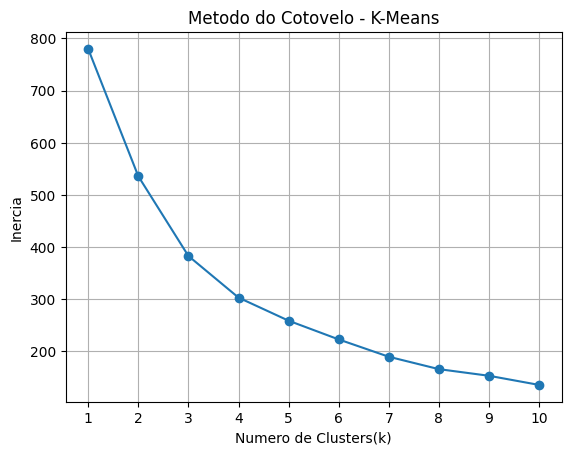

In [ ]:
#Metodo do Cotovelo para escolher o numero de clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
inercias = []
for k in range(1, 11):
  kmeans = KMeans(n_clusters=k,random_state=42, n_init=10)
  kmeans.fit(x_cluster_scaled)
  inercias.append(kmeans.inertia_)
plt.plot(range(1, 11),inercias,marker="o")
plt.xlabel("Numero de Clusters(k)")
plt.ylabel("Inercia")
plt.title("Metodo do Cotovelo - K-Means")
plt.xticks(range(1, 11))
plt.grid()
plt.show()

In [ ]:
#Aplicando o K-Means com 4 clusters
kmeans_final = KMeans(n_clusters=4,random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(x_cluster_scaled)
#Adicionando os clusters ao conjunto de dados
df["Cluster"] = clusters
print("Clusterização concluida!")
print("\nQuantidade de registros por cluster:")
print(df["Cluster"].value_counts().sort_index())

Clusterização concluida!

Quantidade de registros por cluster:
Cluster
0    26
1    36
2    51
3    43
Name: count, dtype: int64


In [ ]:
#Analisando as caracteristicas medias de cada cluster
medias_clusters = df.groupby("Cluster")[colunas_cluster].mean()
print("Media das variaveis por cluster:")
display(medias_clusters.round(2))

Media das variaveis por cluster:


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
Cluster,,,,,
0,2610.11,18.32,85.20,26.20,178310.15
1,2353.61,18.41,84.11,26.51,29671.42
2,2733.52,18.34,85.65,26.12,16624.00
3,2230.03,17.80,83.90,25.98,51344.74


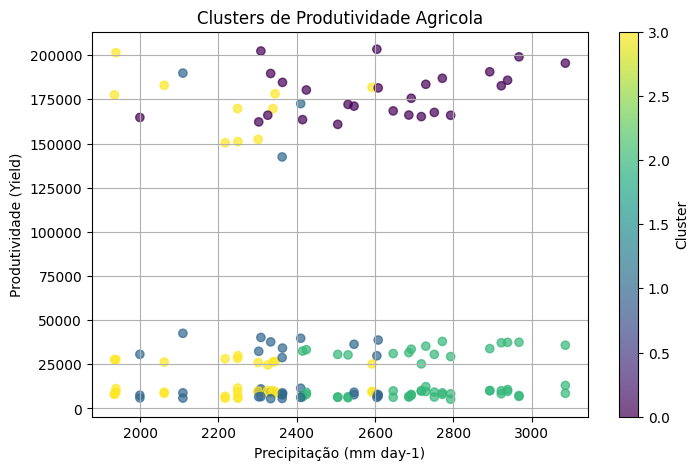

In [ ]:
#Visualização dos clusters: Precipitação x Yield
plt.figure(figsize=(8, 5))
plt.scatter(df["Precipitation (mm day-1)"], df["Yield"], c=df["Cluster"], cmap="viridis", alpha=0.7)
plt.xlabel("Precipitação (mm day-1)")
plt.ylabel("Produtividade (Yield)")
plt.title("Clusters de Produtividade Agricola")
plt.colorbar(label="Cluster")
plt.grid()
plt.show()

### Análise dos Clusters de Produtividade

A análise de clusterização permitiu identificar diferentes grupos de comportamento relacionados à produtividade agrícola. O gráfico apresenta a relação entre a precipitação e o rendimento das culturas, permitindo visualizar grupos com características semelhantes.

Observa-se que existem diferentes níveis de produtividade mesmo para condições de precipitação próximas, indicando que a chuva, isoladamente, não explica todo o rendimento agrícola. Outras variáveis presentes no conjunto de dados, como temperatura e umidade, também podem influenciar a produtividade.

A clusterização também auxilia na identificação de observações com comportamento diferente da maioria dos dados, que podem representar possíveis outliers e devem ser consideradas durante a análise dos modelos preditivos.

## Modelos Preditivos de Regressão

Nesta etapa serão desenvolvidos e comparados cinco modelos de Machine Learning utilizando diferentes algoritmos de regressão supervisionada. O objetivo é prever o rendimento das culturas (Yield) a partir das condições ambientais presentes no conjunto de dados.

Os modelos serão avaliados por métricas de regressão, permitindo comparar seus desempenhos e identificar qual apresenta a melhor capacidade preditiva.

In [ ]:
#Preparação dos dados para os modelos de regressão
from sklearn.model_selection import train_test_split
#Variaveis utilizadas para prever a produtividade
X = df.drop(columns=["Yield","Cluster"])
#Variavel que queremos prever
y = df["Yield"]
#Transformar variaveis categoricas em variaveis numericas
X = pd.get_dummies(X, drop_first=True)
#Separação dos dados: 80% para treinamento e 20% para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print("Dados de treinamento:", X_train.shape)
print("Dados de teste:", X_test.shape)

Dados de treinamento: (124, 7)
Dados de teste: (32, 7)


In [ ]:
# MODELO 1 - REGRESSÃO LINEAR

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Criar e treinar o modelo
modelo_linear = LinearRegression()
modelo_linear.fit(X_train, y_train)

# Fazer previsões com os dados de teste
y_pred_linear = modelo_linear.predict(X_test)

# Avaliar o modelo
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Modelo 1 - Regressão Linear")
print(f"MAE: {mae_linear:.2f}")
print(f"RMSE: {rmse_linear:.2f}")
print(f"R²: {r2_linear:.4f}")

Modelo 1 - Regressão Linear
MAE: 3132.80
RMSE: 4394.17
R²: 0.9950


In [ ]:
# MODELO 2 - ÁRVORE DE DECISÃO

from sklearn.tree import DecisionTreeRegressor

# Criar e treinar o modelo
modelo_arvore = DecisionTreeRegressor(random_state=42)
modelo_arvore.fit(X_train, y_train)

# Fazer previsões
y_pred_arvore = modelo_arvore.predict(X_test)

# Avaliar o modelo
mae_arvore = mean_absolute_error(y_test, y_pred_arvore)
rmse_arvore = np.sqrt(mean_squared_error(y_test, y_pred_arvore))
r2_arvore = r2_score(y_test, y_pred_arvore)

print("Modelo 2 - Árvore de Decisão")
print(f"MAE: {mae_arvore:.2f}")
print(f"RMSE: {rmse_arvore:.2f}")
print(f"R²: {r2_arvore:.4f}")

Modelo 2 - Árvore de Decisão
MAE: 3142.53
RMSE: 5316.35
R²: 0.9927


In [ ]:
# MODELO 3 - RANDOM FOREST

from sklearn.ensemble import RandomForestRegressor

# Criar e treinar o modelo
modelo_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

# Fazer previsões
y_pred_rf = modelo_rf.predict(X_test)

# Avaliar o modelo
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Modelo 3 - Random Forest")
print(f"MAE: {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R²: {r2_rf:.4f}")

Modelo 3 - Random Forest
MAE: 2802.37
RMSE: 4881.96
R²: 0.9939


In [ ]:
# MODELO 4 - GRADIENT BOOSTING

from sklearn.ensemble import GradientBoostingRegressor

# Criar e treinar o modelo
modelo_gb = GradientBoostingRegressor(random_state=42)
modelo_gb.fit(X_train, y_train)

# Fazer previsões
y_pred_gb = modelo_gb.predict(X_test)

# Avaliar o modelo
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Modelo 4 - Gradient Boosting")
print(f"MAE: {mae_gb:.2f}")
print(f"RMSE: {rmse_gb:.2f}")
print(f"R²: {r2_gb:.4f}")

Modelo 4 - Gradient Boosting
MAE: 3108.84
RMSE: 6058.89
R²: 0.9905


In [ ]:
# MODELO 5 - K-NEAREST NEIGHBORS (KNN)

from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

# Padronizar os dados, pois o KNN é sensível à escala das variáveis
scaler = StandardScaler()

X_train_knn = scaler.fit_transform(X_train)
X_test_knn = scaler.transform(X_test)

# Criar e treinar o modelo
modelo_knn = KNeighborsRegressor(n_neighbors=5)
modelo_knn.fit(X_train_knn, y_train)

# Fazer previsões
y_pred_knn = modelo_knn.predict(X_test_knn)

# Avaliar o modelo
mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

print("Modelo 5 - KNN Regressor")
print(f"MAE: {mae_knn:.2f}")
print(f"RMSE: {rmse_knn:.2f}")
print(f"R²: {r2_knn:.4f}")

Modelo 5 - KNN Regressor
MAE: 2425.86
RMSE: 4606.84
R²: 0.9945


In [ ]:
# Comparação dos cinco modelos de regressão

resultados = pd.DataFrame({
    "Modelo": [
        "Regressão Linear",
        "Árvore de Decisão",
        "Random Forest",
        "Gradient Boosting",
        "KNN"
    ],
    "MAE": [
        mae_linear,
        mae_arvore,
        mae_rf,
        mae_gb,
        mae_knn
    ],
    "RMSE": [
        rmse_linear,
        rmse_arvore,
        rmse_rf,
        rmse_gb,
        rmse_knn
    ],
    "R²": [
        r2_linear,
        r2_arvore,
        r2_rf,
        r2_gb,
        r2_knn
    ]
})

resultados.sort_values(by="R²", ascending=False)

,Modelo,MAE,RMSE,R²
0,Regressão Linear,3132.796384,4394.165819,0.995022
4,KNN,2425.856250,4606.836740,0.994529
2,Random Forest,2802.370938,4881.962383,0.993856
1,Árvore de Decisão,3142.531250,5316.346746,0.992714
3,Gradient Boosting,3108.842605,6058.894234,0.990536


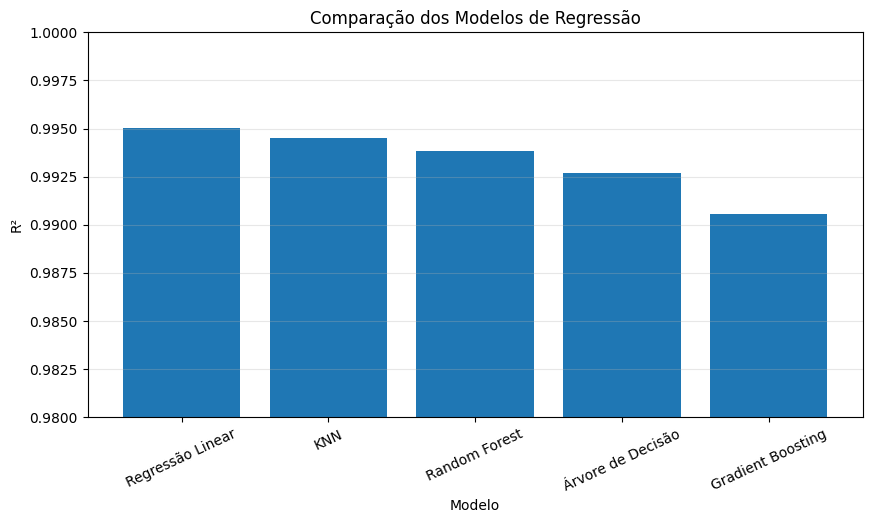

In [ ]:
# Gráfico comparativo do desempenho dos modelos pelo R²

resultados_ordenados = resultados.sort_values(by="R²", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(resultados_ordenados["Modelo"], resultados_ordenados["R²"])

plt.title("Comparação dos Modelos de Regressão")
plt.xlabel("Modelo")
plt.ylabel("R²")
plt.ylim(0.98, 1.0)
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Comparação e Análise dos Modelos

Foram avaliados cinco algoritmos de regressão: Regressão Linear, Árvore de Decisão, Random Forest, Gradient Boosting e K-Nearest Neighbors (KNN).

Todos os modelos apresentaram valores elevados de R² no conjunto de teste. A Regressão Linear apresentou o maior R² (0,9950) e o menor RMSE (4.394,17), indicando bom desempenho geral na previsão do rendimento das culturas. O KNN apresentou resultado muito próximo, com R² de 0,9945, além de obter o menor MAE (2.425,86).

O Random Forest também apresentou desempenho elevado, com R² de 0,9939. A Árvore de Decisão obteve R² de 0,9927, enquanto o Gradient Boosting apresentou R² de 0,9905.

Considerando conjuntamente as métricas MAE, RMSE e R², a Regressão Linear apresentou o melhor equilíbrio entre os modelos avaliados neste conjunto de teste.

### Pontos Fortes e Limitações

Como ponto forte, foram utilizados diferentes algoritmos de regressão e métricas complementares para avaliar o desempenho preditivo.

Como limitação, o conjunto de dados possui uma quantidade relativamente pequena de registros e a avaliação foi realizada utilizando uma única divisão entre treinamento e teste. Portanto, os resultados podem variar com outras amostras. Como trabalho futuro, poderiam ser utilizadas técnicas de validação cruzada e ajuste de hiperparâmetros para obter uma avaliação mais robusta.